In [58]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [59]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [60]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [61]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [62]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_3932795/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date     Timestamp Hand HoldTime Direction  \
0                 0  0EA27ICBLF  160722  18:41:04.336    L   0101.6        LL   
1                 1  0EA27ICBLF  160722  18:42:14.070    L   0085.9        LL   
2                 2  0EA27ICBLF  160722  18:42:14.273    L   0078.1        LL   
3                 3  0EA27ICBLF  160722  18:42:14.617    L   0062.5        LL   
4                 4  0EA27ICBLF  160722  18:42:15.586    S   0125.0        LS   
...             ...         ...     ...           ...  ...      ...       ...   
9316853     9316853  ZYWLN4JVLA  170126  13:56:20.117    L   0195.3        RL   
9316854     9316854  ZYWLN4JVLA  170126  13:56:20.242    R   0105.5        LR   
9316855     9316855  ZYWLN4JVLA  170126  13:56:33.625    L   0168.0        LL   
9316856     9316856  ZYWLN4JVLA  170126  13:56:33.836    L   0097.7        LL   
9316857     9316857  ZYWLN4JVLA  170126  13:56:34.066    L   0168.0        LL   

        LatencyTime FlightT

In [63]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [64]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [ ]:
#Still left with 9M rows, so deleting columns with duplicates userkeys 

df = df.groupby("UserKey").head(100).reset_index(drop=True)

In [66]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172078,9309199,ZYWLN4JVLA,170121,13:54:20.340,R,0007.8,RR,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172079,9309200,ZYWLN4JVLA,170121,13:54:20.453,L,0121.1,RL,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172080,9309201,ZYWLN4JVLA,170121,13:54:20.539,S,0207.0,LS,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172081,9309202,ZYWLN4JVLA,170121,13:54:26.406,L,0316.4,SL,0675.8,410.2,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [67]:
import pandas as pd

label_col = 'Parkinsons'  # Replace with your actual label column

# 1. Find number of samples in the smallest class
min_count = df[label_col].value_counts().min()

# 2. Sample 'min_count' examples from each class
df = df.groupby(label_col).sample(n=min_count, random_state=42)

# 3. Shuffle the final balanced dataframe (optional but recommended)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [68]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,1876028,9RCEHVGNCJ,170226,10:38:06.430,L,183.6,LL,339.8,199.2,9RCEHVGNCJ_1702.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
1,4288863,KRJVEQSLL5,170303,10:00:42.098,L,54.7,SL,300.8,238.3,KRJVEQSLL5_1703.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
2,1875928,9RCEHVGNCJ,170226,10:34:49.695,L,175.8,SL,785.2,671.9,9RCEHVGNCJ_1702.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
3,3934286,HAEZ2A3NM5,160710,10:09:07.375,L,66.4,RL,250.0,171.9,HAEZ2A3NM5_1607.txt,...,True,True,2013,Left,Don't know,Mild,False,False,False,False
4,7904604,WBS5I7VF1G,160815,16:23:33.656,R,0187.5,RR,0234.4,31.3,WBS5I7VF1G_1608.txt,...,True,False,2016,Right,Don't know,Medium,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86789,6745593,QXLSWXKHEX,160825,12:13:22.641,S,15.6,RS,242.2,449.2,QXLSWXKHEX_1608.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
86790,308467,5USOYSDCXB,170208,10:07:43.902,L,78.1,LL,234.4,156.3,5USOYSDCXB_1702.txt,...,True,True,2017,NaN,Don't know,Mild,False,False,False,False
86791,2828359,CPSM4LIXDS,170116,20:26:20.094,L,0046.9,LL,0515.6,453.1,CPSM4LIXDS_1701.txt,...,True,False,2016,Right,Don't know,Severe,False,False,False,True
86792,4707695,MG8XVA5BFA,160809,18:52:37.719,R,0085.9,LR,0218.8,46.9,MG8XVA5BFA_1608.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False


In [69]:
df["Parkinsons"].value_counts()

Parkinsons
False    43397
True     43397
Name: count, dtype: int64

In [70]:
df["Parkinsons"].value_counts()

#Will balance this during preprocessing 

Parkinsons
False    43397
True     43397
Name: count, dtype: int64

In [71]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    84794
4               677
3               663
2               659
1                 1
Name: count, dtype: int64

In [72]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "UPDRS", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])


In [73]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [74]:
df.head(10)

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,183.6,LL,339.8,199.2,False,False
1,L,54.7,SL,300.8,238.3,False,True
2,L,175.8,SL,785.2,671.9,False,False
3,L,66.4,RL,250.0,171.9,True,True
4,R,0187.5,RR,0234.4,31.3,True,False
5,R,89.8,LR,226.6,113.3,False,True
6,R,93.8,LR,460.9,367.2,True,True
7,L,125.0,LL,406.3,187.5,False,True
8,R,0109.4,LR,0273.4,0156.3,True,False
9,S,97.7,SS,156.3,70.3,True,False


In [75]:
print(df["Hand"].unique())

['L' 'R' 'S' '160705' '11:02:57.906' '160830' '160628' '160918' '170211'
 '160821']


In [76]:
print(df["Direction"].unique())

['LL' 'SL' 'RL' 'RR' 'LR' 'SS' 'LS' 'RS' 'SR' 'LLZWBPPNQCUX' 'L' '0109.4'
 'R' 'SYUUDFV8IU' '160826' 'KTUVFFSLN4']


In [77]:
#Dropping rows with weird labels for categorical columns, hands and directions
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,183.6,LL,339.8,199.2,False,False
1,L,54.7,SL,300.8,238.3,False,True
2,L,175.8,SL,785.2,671.9,False,False
3,L,66.4,RL,250.0,171.9,True,True
4,R,0187.5,RR,0234.4,31.3,True,False
...,...,...,...,...,...,...,...
86788,L,0175.8,LL,0031.3,0113.3,True,True
86790,L,78.1,LL,234.4,156.3,True,True
86791,L,0046.9,LL,0515.6,453.1,True,True
86792,R,0085.9,LR,0218.8,46.9,False,False


In [78]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    40922
R    32257
Name: count, dtype: int64
['L' 'R']


In [79]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,183.6,LL,339.8,199.2,False,False
3,L,66.4,RL,250.0,171.9,True,True
4,R,0187.5,RR,0234.4,31.3,True,False
5,R,89.8,LR,226.6,113.3,False,True
6,R,93.8,LR,460.9,367.2,True,True
...,...,...,...,...,...,...,...
86788,L,0175.8,LL,0031.3,0113.3,True,True
86790,L,78.1,LL,234.4,156.3,True,True
86791,L,0046.9,LL,0515.6,453.1,True,True
86792,R,0085.9,LR,0218.8,46.9,False,False


 LightBGM modeling-specific Label Encoding Categorical Variables 

In [80]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[0 2 3 1]


In [81]:
print(df["Hand"].unique())

[0 1]


In [82]:
print(df["Direction"])

0        0
3        2
4        3
5        1
6        1
        ..
86788    0
86790    0
86791    0
86792    1
86793    1
Name: Direction, Length: 64437, dtype: int64


In [83]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
Gender_Male      bool
dtype: object


In [84]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [85]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [86]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
Gender_Male       bool
dtype: object


In [87]:
#Viewing all the rows in teh dataset

In [88]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [89]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64" and col != "Parkinsons"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [90]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [91]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,183.6,0,339.8,199.2,False,False
3,0,66.4,2,250.0,171.9,True,True
4,1,187.5,3,234.4,31.3,True,False
5,1,89.8,1,226.6,113.3,False,True
6,1,93.8,1,460.9,367.2,True,True
...,...,...,...,...,...,...,...
86788,0,175.8,0,31.3,113.3,True,True
86790,0,78.1,0,234.4,156.3,True,True
86791,0,46.9,0,515.6,453.1,True,True
86792,1,85.9,1,218.8,46.9,False,False


In [92]:
#Removing outliers for robustness

def remove_outliers_iqr(df, cols, factor=0.75):
    
    df_clean = df.copy()
    mask = pd.Series([True] * df.shape[0], index=df.index)

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Only keep rows within bounds for this column
        mask &= df[col].between(lower_bound, upper_bound)

    return df[mask]

df_clean = remove_outliers_iqr(df, ["HoldTime", "LatencyTime", "FlightTime"])

df = df_clean.copy()


In [93]:
print(df_clean)

       Hand  HoldTime  Direction  LatencyTime  FlightTime  Parkinsons  \
0         0     183.6          0        339.8       199.2       False   
3         0      66.4          2        250.0       171.9        True   
4         1     187.5          3        234.4        31.3        True   
5         1      89.8          1        226.6       113.3       False   
6         1      93.8          1        460.9       367.2        True   
...     ...       ...        ...          ...         ...         ...   
86788     0     175.8          0         31.3       113.3        True   
86790     0      78.1          0        234.4       156.3        True   
86791     0      46.9          0        515.6       453.1        True   
86792     1      85.9          1        218.8        46.9       False   
86793     1      78.1          1        156.3        46.9       False   

       Gender_Male  
0            False  
3             True  
4            False  
5             True  
6             True

In [94]:
#Using robust scaler 
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scale_list = ["HoldTime", "LatencyTime", "FlightTime"]
for col in scale_list:
    df[col] = scaler.fit_transform(df[[col]])

df 


,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,1.366894,0,0.359959,0.136126,False,False
3,0,-0.633106,2,-0.099846,-0.022688,True,True
4,1,1.433447,3,-0.179724,-0.840605,True,False
5,1,-0.233788,1,-0.219662,-0.363583,False,True
6,1,-0.165529,1,0.980031,1.113438,True,True
...,...,...,...,...,...,...,...
86788,0,1.233788,0,-1.219662,-0.363583,True,True
86790,0,-0.433447,0,-0.179724,-0.113438,True,True
86791,0,-0.965870,0,1.260113,1.613147,True,True
86792,1,-0.300341,1,-0.259601,-0.749855,False,False


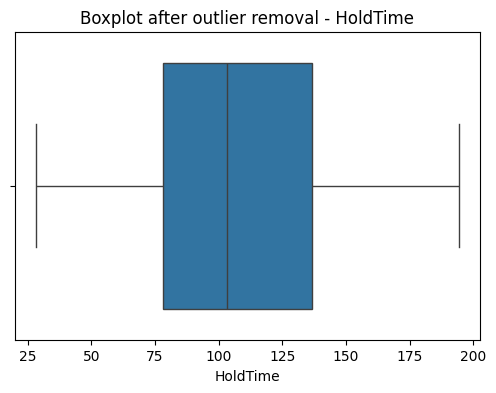

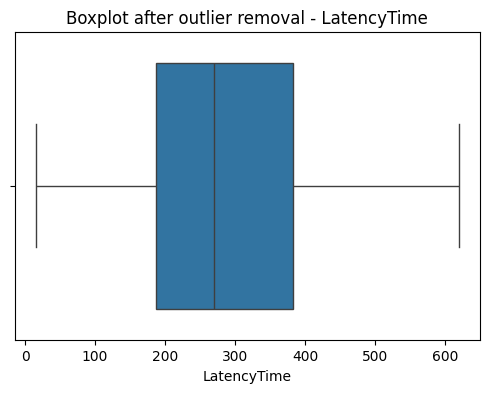

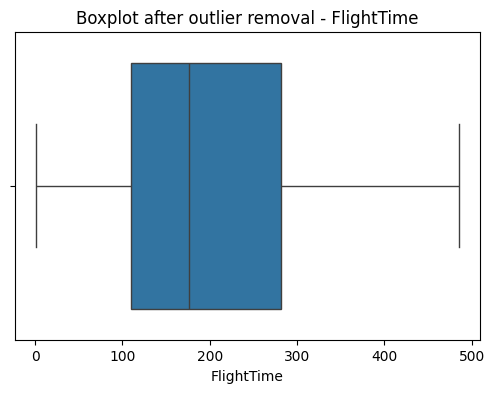

In [95]:
#Visulizing with box plots
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["HoldTime", "LatencyTime", "FlightTime"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot after outlier removal - {col}")
    plt.show()

In [96]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [97]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[0.46196377 0.06429578 1.37866105 0.10354008 0.12663932]


In [98]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [99]:
#Visualizations 

import numpy as np


In [100]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,1.366894,0,0.359959,0.136126,False,False
3,0,-0.633106,2,-0.099846,-0.022688,True,True
4,1,1.433447,3,-0.179724,-0.840605,True,False
5,1,-0.233788,1,-0.219662,-0.363583,False,True
6,1,-0.165529,1,0.980031,1.113438,True,True
...,...,...,...,...,...,...,...
86788,0,1.233788,0,-1.219662,-0.363583,True,True
86790,0,-0.433447,0,-0.179724,-0.113438,True,True
86791,0,-0.965870,0,1.260113,1.613147,True,True
86792,1,-0.300341,1,-0.259601,-0.749855,False,False


In [101]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[ 1.3668942  -0.6331058   1.4334471  -0.2337884  -0.16552901  0.3668942
  0.10068259 -0.5        -0.03242321 -0.6996587  -0.5665529   1.10068259
  0.6331058  -0.83276451 -0.09897611 -0.3003413   0.4334471   0.6996587
 -0.16211604 -0.4334471   1.03412969  1.16723549  0.16723549 -0.3668942
  0.2337884  -1.23208191  0.1331058   1.2337884  -0.7337884  -0.1331058
  0.3003413   0.83276451  0.46757679  1.01535836  0.5         0.96757679
 -0.96587031 -1.          0.90102389  0.2662116   1.3003413   0.68430034
  1.21672355 -0.89931741  0.7662116   0.03412969 -1.09897611  0.5665529
 -1.1331058   0.38395904  0.1996587   0.0665529   1.5        -1.0665529
  0.9334471  -0.0665529   1.23720137 -1.16552901 -0.7662116  -0.2662116
  0.28156997  0.62116041 -0.39931741  0.29863481  0.45221843 -0.18259386
  0.12457338  1.33276451  0.19624573 -0.70819113  0.          1.04948805
 -0.53242321  0.00853242 -1.03242321  0.34982935  0.82935154 -0.1996587
  0.7337884  -0.59897611  1.         

In [102]:
park_scaled = df["Parkinsons"]

In [103]:
park_scaled.isna().sum()

0

In [104]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

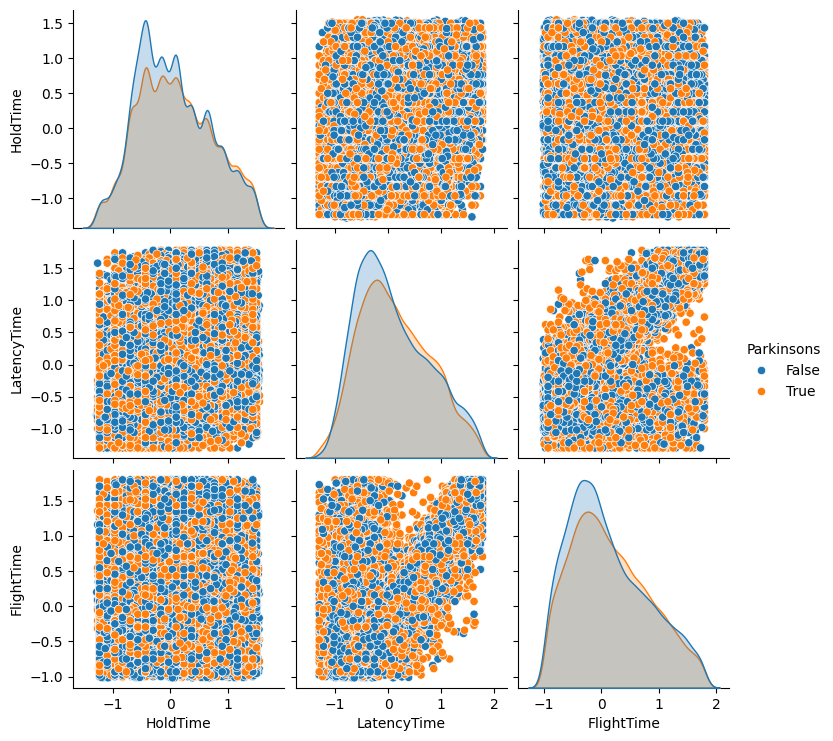

In [105]:
plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
plt.show()

Heatmap Correlations

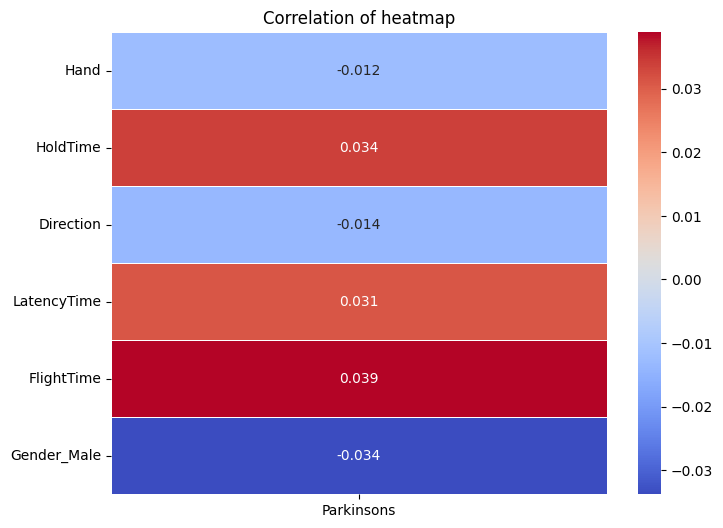

In [106]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

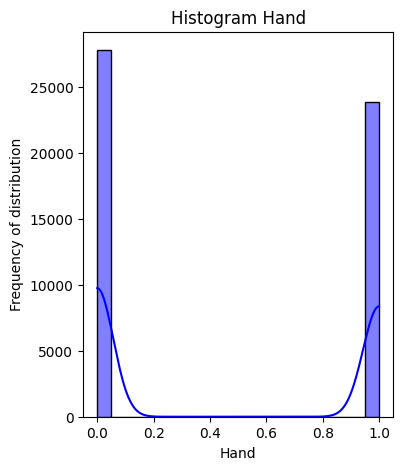

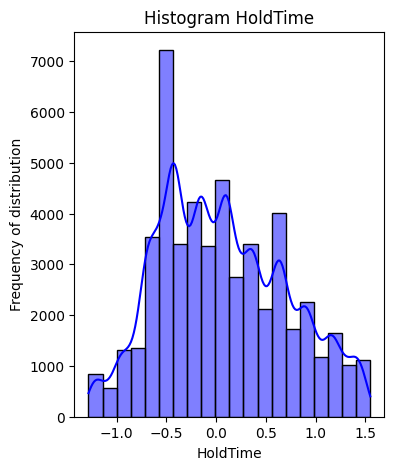

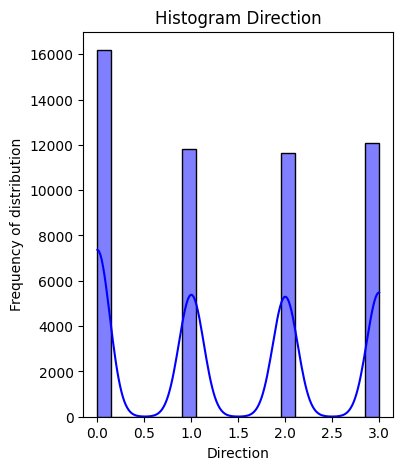

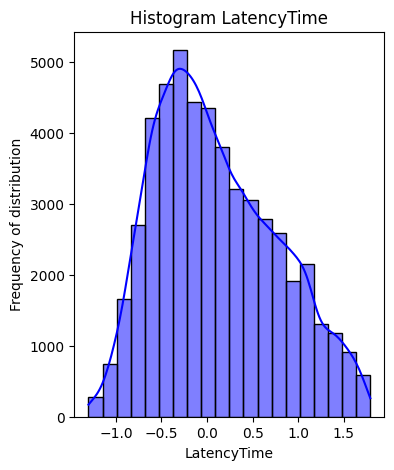

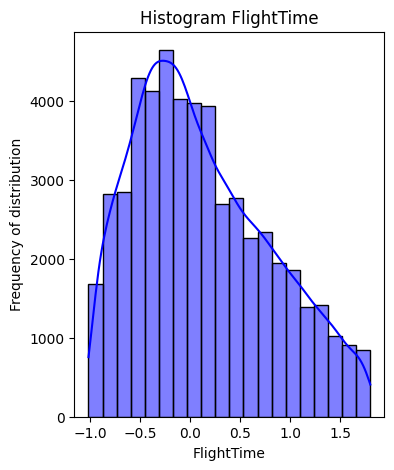

In [107]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [108]:
len(num_columns)
print(num_columns)

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [109]:
#Creating a dataframe with the scaled data and visualizing it again
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime
0,-0.926613,2.035899,-1.196553,0.383238,0.014051
1,-0.926613,-1.090005,0.539266,-0.303976,-0.221183
2,1.079200,2.139918,1.407176,-0.423359,-1.432679
3,1.079200,-0.465891,-0.328644,-0.483050,-0.726116
4,1.079200,-0.359205,-0.328644,1.309982,1.461643
...,...,...,...,...,...
51722,-0.926613,1.827861,-1.196553,-1.977626,-0.726116
51723,-0.926613,-0.777948,-1.196553,-0.423359,-0.355602
51724,-0.926613,-1.610100,-1.196553,1.728585,2.201810
51725,1.079200,-0.569910,-0.328644,-0.542741,-1.298260


Histogram visualizations

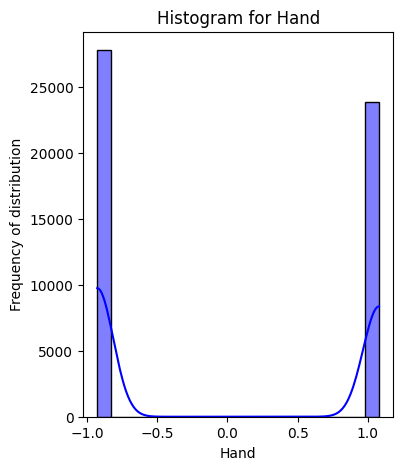

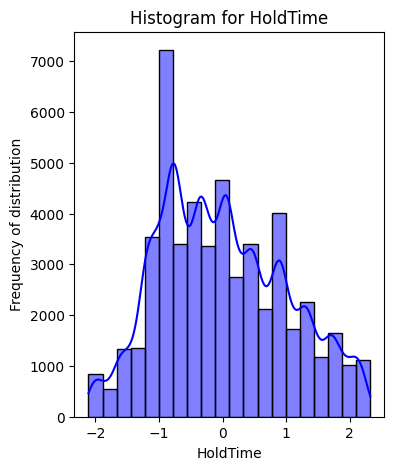

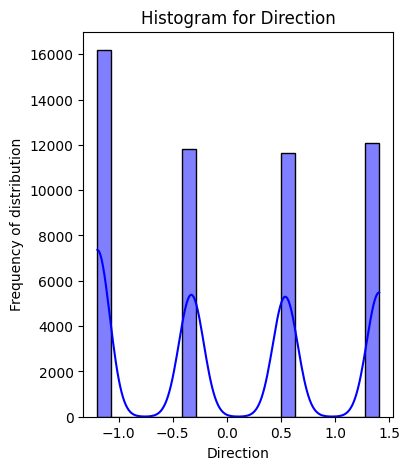

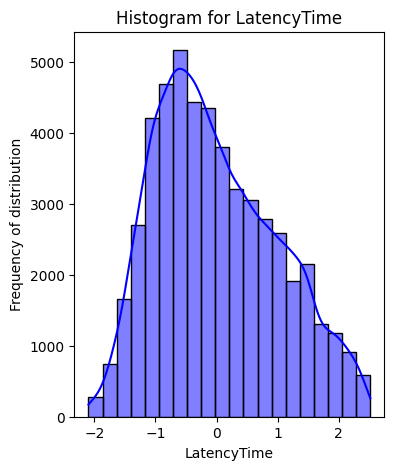

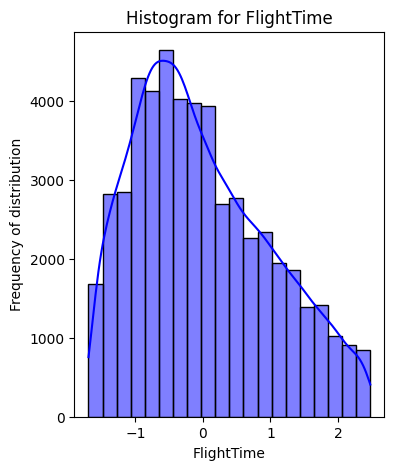

In [110]:
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

Heatmap Visualizations

In [111]:
df_scaled["Parkinsons"] = park_scaled.reset_index(drop=True)

In [112]:
df_scaled["Parkinsons"].isna().sum()

0

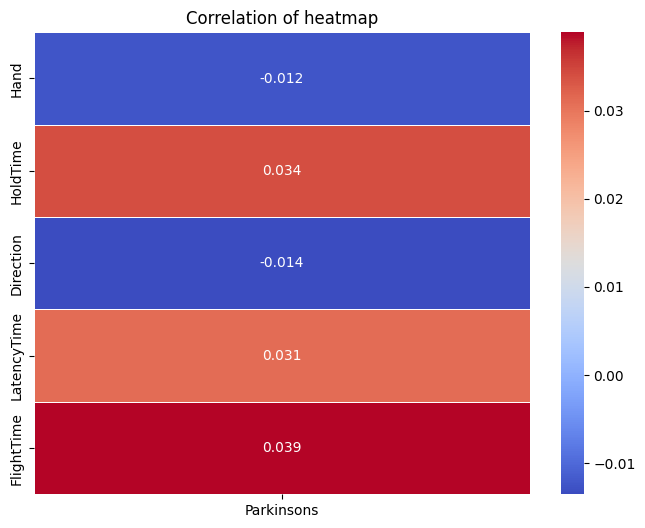

In [113]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


In [114]:
#Exporting this in the file directory for storage for a neural network

df_scaled.to_csv("nn.csv", index=False)